# Short-Therm Memory with the InMemorySaver Class


In [1]:
%load_ext mypy_ipython

### Import Relevant Classes and Functions

In [2]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_ollama import ChatOllama
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, RemoveMessage
from typing import Literal
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from pathlib import Path

### Define the State

In [3]:
class State(MessagesState):
    summary: str

In [4]:
test_state = State()

In [ ]:
test_state["summary"]

In [ ]:
bool(test_state.get("summary", ""))

### Define the Nodes

In [5]:
chat = ChatOllama( model= 'llama3.2',seed=365, temperature=0, num_predict=256)

In [6]:
def ask_question(state: State) -> State:
    
    print(f"\n-------> ENTERING ask_question:")
    
    question = "What is your question?"
    print(question)
    
    return State(messages = [AIMessage(question), HumanMessage(input())])

In [7]:
def chatbot(state: State) -> State:
    
    print(f"\n-------> ENTERING chatbot:")
    for i in state["messages"]:
        i.pretty_print()
        
    system_message = f'''
    Here's a quick summary of what's been discussed so far:
    {state.get("summary", "")}
    
    Keep this in mind as you answer the next question.
    '''
    
    response = chat.invoke([SystemMessage(system_message)] + state["messages"])
    response.pretty_print()
    
    return State(messages = [response])

In [8]:
def ask_another_question(state: State) -> State:
    
    print(f"\n-------> ENTERING ask_another_question:")
    
    question = "Would you like to ask one more question (yes/no)?"
    print(question)
    
    return State(messages = [AIMessage(question), HumanMessage(input())])

In [9]:
def summarize_and_delete_messages(state: State) -> State:
    print(f"\n-------> ENTERING trim_messages:")
    
    new_conversation = ""
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content}\n\n"
        
    summary_instructions = f'''
Update the ongoing summary by incorporating the new lines of conversation below.  
Build upon the previous summary rather than repeating it so that the result  
reflects the most recent context and developments.


Previous Summary:
{state.get("summary", "")}

New Conversation:
{new_conversation}
'''
    
    print(summary_instructions)
    
    summary = chat.invoke([HumanMessage(summary_instructions)])
    
    remove_messages = [RemoveMessage(id = i.id) for i in state["messages"][:]]
    
    return State(messages = remove_messages, summary = summary.content)

### Define the Routing Function

In [10]:
def routing_function(state: State) -> Literal["summarize_and_delete_messages", "__end__"]:
    
    if state["messages"][-1].content == "yes":
        return "summarize_and_delete_messages"
    else:
        return "__end__"

### Define the Graph

In [ ]:
graph = StateGraph(State)

In [ ]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)
graph.add_node("summarize_and_delete_messages", summarize_and_delete_messages)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_conditional_edges(source = "ask_another_question", 
                            path = routing_function)
graph.add_edge("summarize_and_delete_messages", "ask_question")

In [ ]:
checkpointer = InMemorySaver()
graph_compiled = graph.compile(checkpointer)

In [ ]:
graph_compiled

### Test the Graph

In [ ]:
graph_compiled.invoke(State(messages = []))

In [ ]:
config1 = {"configurable": {"thread_id": "1"}}

In [ ]:
graph_compiled.invoke(State(), config1)

In [11]:
graph_state = [i for i in graph_compiled.get_state_history(config1)]

NameError: name 'graph_compiled' is not defined

# SQL Lite DB

In [15]:
db_path = "langgraph.db"
connect = sqlite3.connect(database = db_path, check_same_thread = False)

In [16]:
checkpointer = SqliteSaver(connect)

### Define the Graph

In [17]:
graph = StateGraph(State)

In [18]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)
graph.add_node("summarize_and_delete_messages", summarize_and_delete_messages)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_conditional_edges(source = "ask_another_question", 
                            path = routing_function)
graph.add_edge("summarize_and_delete_messages", "ask_question")

In [19]:
graph_compiled = graph.compile(checkpointer)

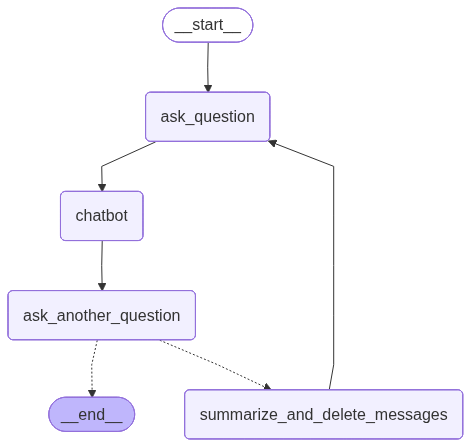

In [20]:
graph_compiled

In [21]:
config1 = {"configurable": {"thread_id": "1"}}

In [ ]:
graph_compiled.invoke(State(), config1)


-------> ENTERING ask_question:
What is your question?


 where he was born?



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Who is the fastest man on the planet?
================================== Ai Message ==================================

The title of "fastest man on the planet" can be subjective and depends on the context, such as track and field events or other activities. However, according to various sources, including Guinness World Records, the current world record holder in the 100m dash is Usain Bolt from Jamaica.

Usain Bolt's top speed has been recorded at approximately 27.78 miles per hour (mph) or 44.64 kilometers per hour (km/h), which he achieved during his 100m dash world record at the 2009 World Championships in Berlin, Germany.

It's worth noting that there are other athletes who have achieved impressive speeds in specific events or activities, such as sprinters in football 